In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np

In [5]:
log_path = "./tests/run_parallel/logs400/"
all_success = []

In [6]:
# Lê os dados e separa em quartis, somando o número de sucessos por operador
for method in range(3):
    csv_files = glob.glob(os.path.join(log_path, f"VNS{method}_*.csv"))
    
    for f in csv_files:
        df = pd.read_csv(f)
        df["Execution"] = os.path.splitext(os.path.basename(f))[0]
        df["Method"] = f"VNS{method}"

        # Ordenar por progresso
        df = df.sort_values(by="Evaluations").reset_index(drop=True)

        # Quartis
        quartil_labels = ['Q1', 'Q2', 'Q3', 'Q4']
        df['Quartil'] = np.concatenate([
            np.repeat(label, len(split)) for label, split in zip(quartil_labels, np.array_split(df.index, 4))
        ])

        # Conta sucessos por operador em cada quartil
        success_counts = (
            df[df["Success"] == 1]
            .groupby(["Operator", "Quartil"])
            .size()
            .reset_index(name="Success Count")
        )
        success_counts["Method"] = f"VNS{method}"
        all_success.append(success_counts)

# Junta tudo
df_success = pd.concat(all_success, ignore_index=True)

# Agora soma os sucessos por operador + quartil + método (30 execuções)
df_grouped = df_success.groupby(["Method", "Operator", "Quartil"])["Success Count"].sum().reset_index()

# Gera um gráfico por VNS
methods = df_grouped["Method"].unique()
quartil_order = ['Q1', 'Q2', 'Q3', 'Q4']

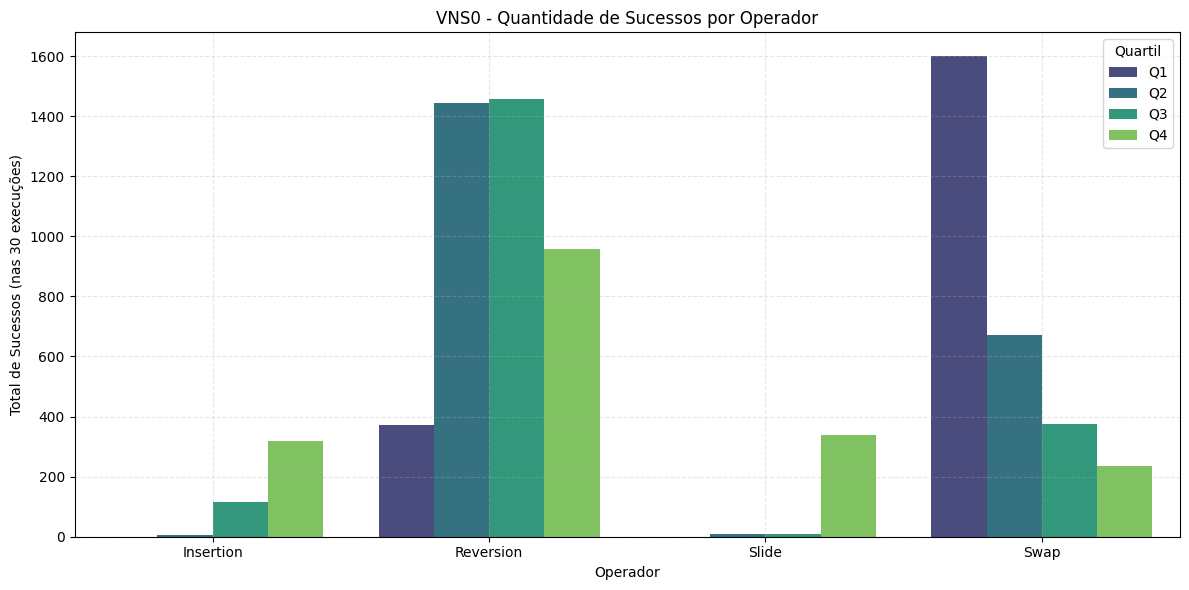

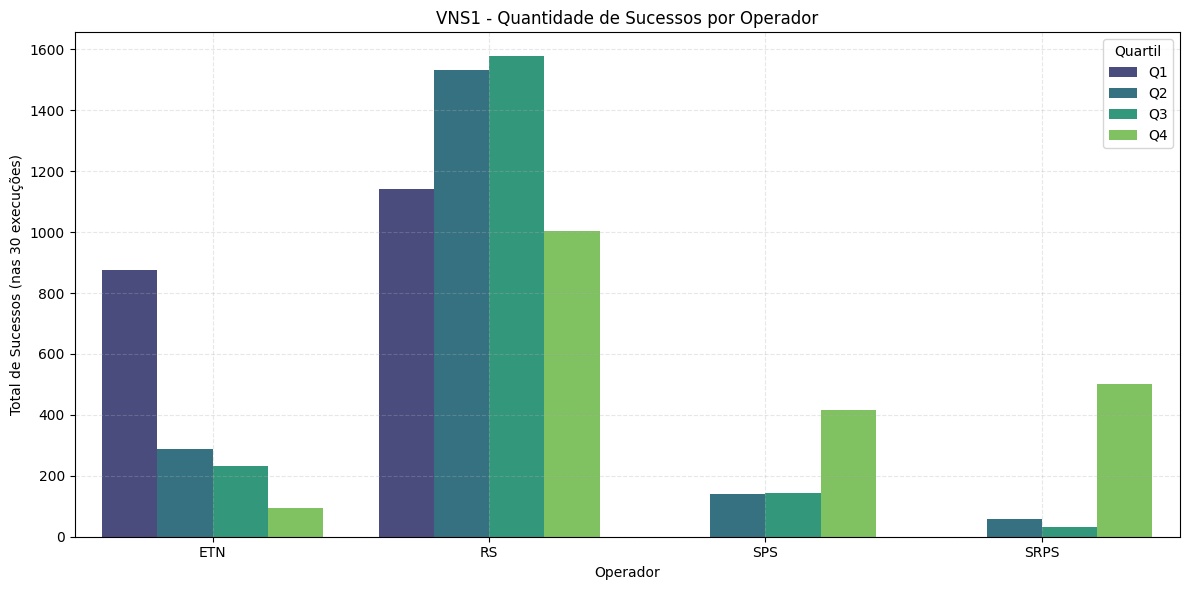

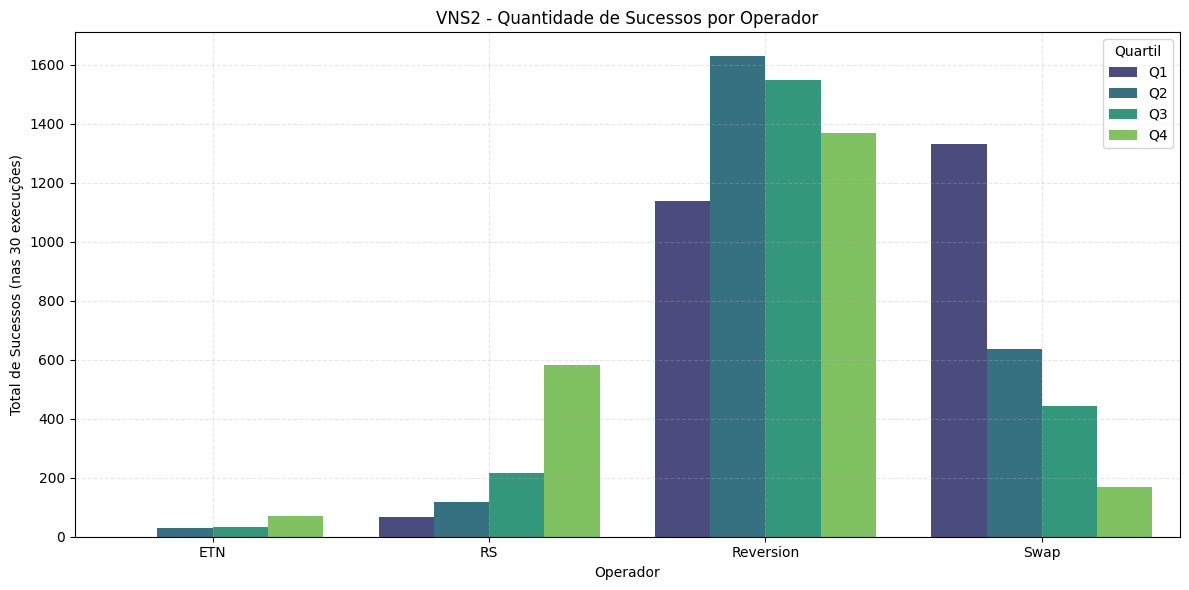

In [8]:
for method in methods:
    plt.figure(figsize=(12, 6))
    subset = df_grouped[df_grouped["Method"] == method]
    
    sns.barplot(
        data=subset,
        x="Operator", y="Success Count", hue="Quartil",
        hue_order=quartil_order, palette="viridis"
    )

    plt.title(f'{method} - Quantidade de Sucessos por Operador')
    plt.xlabel("Operador")
    plt.ylabel("Total de Sucessos (nas 30 execuções)")
    plt.legend(title="Quartil")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()